<a href="https://colab.research.google.com/github/Tapaswini005/MNIST-Classification/blob/main/MNIST_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#Import Libraries

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

In [5]:
#Load Dataset

from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training Images:", x_train.shape)
print("Testing Images:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


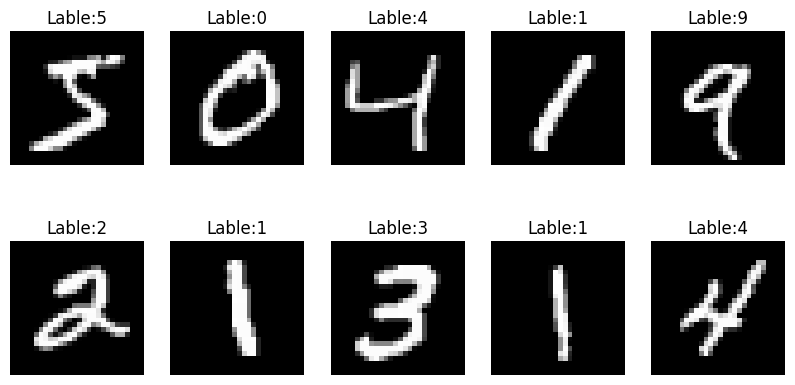

In [6]:
#Display Sample Images

plt.figure(figsize = (10,5))

for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(x_train[i], cmap = 'gray')
  plt.title(f"Lable:{y_train[i]}")
  plt.axis('off')

plt.show()

In [7]:
#Normalize Data

x_train = x_train / 255.0
x_test = x_test / 255.0

In [8]:
#Build Neural Network

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
#Compile Model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
#Train Model

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9204 - loss: 0.2675 - val_accuracy: 0.9579 - val_loss: 0.1401
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9658 - loss: 0.1134 - val_accuracy: 0.9635 - val_loss: 0.1229
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9762 - loss: 0.0789 - val_accuracy: 0.9675 - val_loss: 0.1122
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9813 - loss: 0.0591 - val_accuracy: 0.9728 - val_loss: 0.0984
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9852 - loss: 0.0455 - val_accuracy: 0.9736 - val_loss: 0.0916
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9885 - loss: 0.0352 - val_accuracy: 0.9726 - val_loss: 0.1065
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9895 - loss: 0.0305 - val_accuracy: 0.9689 - val_loss: 0.1232
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9916 - loss: 0.0254 - 

In [11]:
#Evaluate Model

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9768 - loss: 0.1054
Test Accuracy: 0.9768000245094299


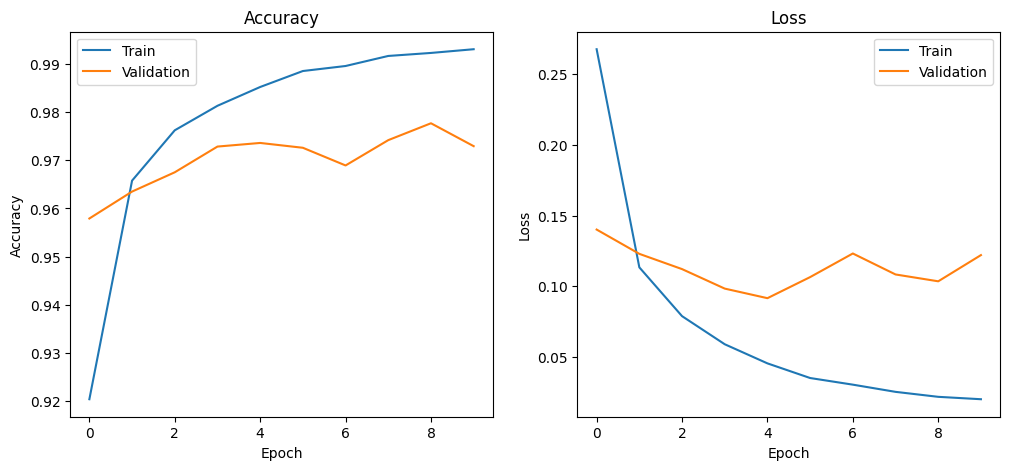

In [12]:
#Plot Accuracy and Loss

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


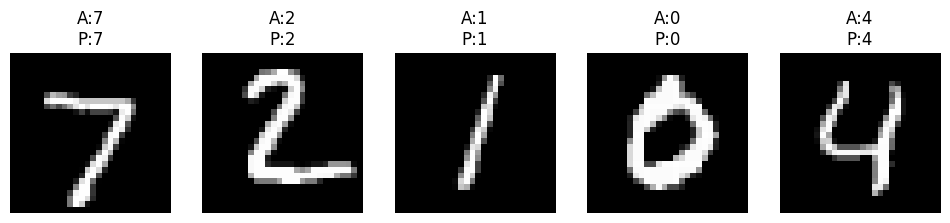

In [13]:
#Predict 5 Images

predictions = model.predict(x_test)

plt.figure(figsize=(12,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_test[i], cmap='gray')

    predicted = np.argmax(predictions[i])

    plt.title(
        f"A:{y_test[i]}\nP:{predicted}"
    )

    plt.axis('off')

plt.show()

In [18]:
#Original Model

Dense(128, activation='relu')
Dense(64, activation='relu')

<Dense name=dense_11, built=False>

In [23]:
#Experiment: Add Dropout

model2 = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

In [24]:
# Compile model


model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
#Train again:

history2 = model2.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9062 - loss: 0.3145 - val_accuracy: 0.9579 - val_loss: 0.1403
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9558 - loss: 0.1452 - val_accuracy: 0.9668 - val_loss: 0.1051
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9662 - loss: 0.1104 - val_accuracy: 0.9705 - val_loss: 0.0979
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9706 - loss: 0.0925 - val_accuracy: 0.9765 - val_loss: 0.0813
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9746 - loss: 0.0788 - val_accuracy: 0.9726 - val_loss: 0.0934
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9777 - loss: 0.0676 - val_accuracy: 0.9750 - val_loss: 0.0914
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9792 - loss: 0.0647 - val_accuracy: 0.9756 - val_loss: 0.0839
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9821 - loss: 0.0557 - 

In [26]:
# Evaluate


test_loss2, test_accuracy2 = model2.evaluate(x_test, y_test)
print("Experiment Accuracy:", test_accuracy2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9767 - loss: 0.0845
Experiment Accuracy: 0.9767000079154968
